Diving deeper into Vegetables and Dry Pulses
Using the same dataset as lecture 6 (https://www.ers.usda.gov/media/5628/vegetables-and-dry-pulses-trade-data.csv?v=74229), please create the following notebook (each bullet point should be a code cell in Google Colab):

- Import the data and store it in a variable
- Clean and filter the data: only keep rows that deal in Thousand dollars (we want a financial analysis), and only the rows specific to Imports.
- Remove countries that are marked as World
Let's analyse the countries the US imports from.
- Create a bar graph that shows the number of countries we import from every year (hint: unique() returns the unique values as a list. nunique() returns the number of unique values).
- After that, display all the countries (as a list) that we imported from in 2024

- Let's see what we spend the most on imports. Find out which commodity we spent the most on in 2025. And in 2024?

- Which country did we import the most from in 2025, in dollar amount?  And in 2017?

- Look back at our most imported commodity (answered above).
Plot a line graph that shows the amount spent on imports of this commodity by year. What do you notice?

- For this same commodity, take a look at the imports made by MonthNumber. Plot a bar graph to see how much was spent on imports every month of the year. Does this match what you could expect?

- We can see if monthly differences are due to lack of US supply or a price increase. Plot the same graph as above, but for Thousand pounds and not Thousand dollars (hint: you'll need to repeat some steps done above, specifically in the the cleaning and filtering section). Doing a visual analysis of the two bar graphs, does the US spend more on imports of the top commodity due to an increase in demand or an increase in price?

In [ ]:
import pandas as pd
df = pd.read_csv("https://www.ers.usda.gov/media/5628/vegetables-and-dry-pulses-trade-data.csv?v=74229")

In [ ]:
# We filter to only have Import data, in Thousand dollars
df = df[(df["Trade"] == "Import") & (df["UnitDesc"] == "Thousand dollars")]


In [ ]:
# We remove the countries marked as "World"
df = df[df["GeographicDesc"] != "World"]

<Axes: xlabel='Year'>

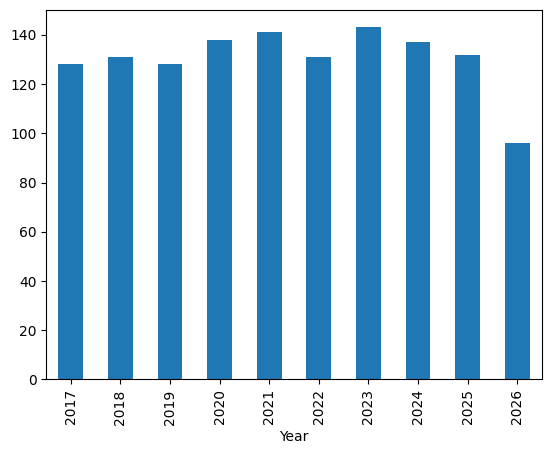

In [ ]:
# We want to display how many countries we import from every year

df.groupby(["Year"])["GeographicDesc"].nunique().plot(kind="bar")

In [ ]:
# We want to look at all the countries we imported from in 2024
list(df[df["Year"] == 2024]["GeographicDesc"].unique())

['Afghanistan',
 'Albania',
 'Argentina',
 'Australia',
 'Belgium',
 'Brazil',
 'Cameroon',
 'Canada',
 'China',
 'Colombia',
 'Costa Rica',
 'Denmark',
 'Egypt',
 'El Salvador',
 'Ethiopia',
 'France',
 'Ghana',
 'Greece',
 'Guatemala',
 'Honduras',
 'Hong Kong',
 'Hungary',
 'India',
 'Israel',
 'Italy',
 'Jordan',
 'Kenya',
 'Lebanon',
 'Madagascar (Malagasy)',
 'Mexico',
 'Burma',
 'New Zealand',
 'Nicaragua',
 'Nigeria',
 'Paraguay',
 'Peru',
 'Poland',
 'Portugal',
 'South Africa',
 'Serbia',
 'South Korea',
 'Taiwan',
 'Tanzania',
 'Thailand',
 'Trinidad and Tobago',
 'Turkey',
 'Ukraine',
 'United Arab Emirates',
 'United Kingdom',
 'Vietnam',
 'Armenia',
 'Austria',
 'Azerbaijan',
 'Bangladesh',
 'Bosnia-Hercegovina',
 'Bulgaria',
 'Cambodia',
 'Chile',
 'Croatia',
 'Czech Republic',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Fiji',
 'Germany',
 'Haiti',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Ivory Coast',
 'Jamaica',
 'Japan',
 'Kosovo',
 'Latvia',
 'Lithuania',

In [ ]:
# Find out which commodity we spent the most on in 2025. And in 2024?
# df_2025 = df[df["Year"] == 2025]
# print("2025:")
# print(df_2025.groupby("CommodityName")["Amount"].sum().sort_values(ascending=False).head(1))
# df_2024 = df[df["Year"] == 2024]
# print("2024:")
# print(df_2024.groupby("CommodityName")["Amount"].sum().sort_values(ascending=False).head(1))

def get_top_import(year: int, filtering_group: str):
  print(f"Getting top import in {year} by {filtering_group}")
  df_by_year = df[df["Year"] == year]
  return df_by_year.groupby(filtering_group)["Amount"].sum().sort_values(ascending=False).head(1)

print(get_top_import(2025, "CommodityName"))
print(get_top_import(2024, "CommodityName"))

Getting top import in 2025 by CommodityName
CommodityName
Tomatoes    3690460.138
Name: Amount, dtype: float64
Getting top import in 2024 by CommodityName
CommodityName
Tomatoes    4536362.8
Name: Amount, dtype: float64


In [ ]:
# Which country did we import the most from in 2025, in dollar amount? And in 2017?
print(get_top_import(2025, "GeographicDesc"))
print()
print(get_top_import(2017, "GeographicDesc"))

Getting top import in 2025 by GeographicDesc
GeographicDesc
Mexico    8738887.924
Name: Amount, dtype: float64

Getting top import in 2017 by GeographicDesc
GeographicDesc
Mexico    6321882.325
Name: Amount, dtype: float64


<Axes: xlabel='Year'>

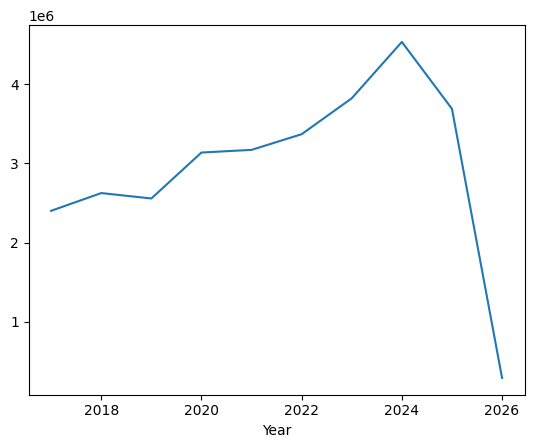

In [ ]:
# Look back at our most imported commodity (answered above).
# Plot a line graph that shows the amount spent on imports of this
# commodity by year. What do you notice?

df_tomatoes = df[df["CommodityName"] == "Tomatoes"]
df_tomatoes.groupby("Year")["Amount"].sum().plot(kind="line")

<Axes: xlabel='MonthNumber'>

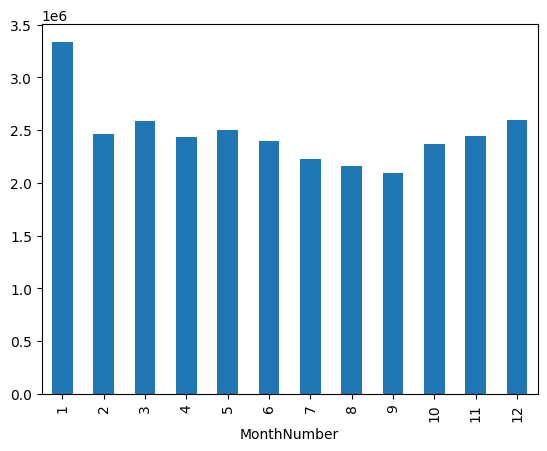

In [ ]:
# For this same commodity, take a look at the imports made by MonthNumber.
# Plot a bar graph to see how much was spent on imports every month of the year.
# Does this match what you could expect?

df_tomatoes.groupby("MonthNumber")["Amount"].sum().plot(kind="bar")

<Axes: xlabel='MonthNumber'>

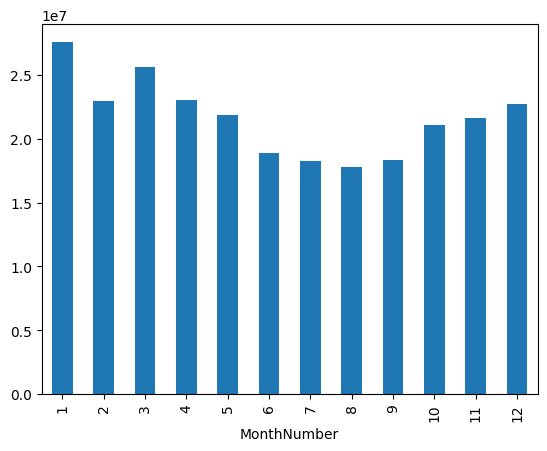

In [ ]:
"""
We can see if monthly differences are due to lack of US supply or a
price increase. Plot the same graph as above, but for Thousand pounds
and not Thousand dollars (hint: you'll need to repeat some steps done above,
specifically in the the cleaning and filtering section). Doing a visual analysis
 of the two bar graphs, does the US spend more on imports of the top commodity due
 to an increase in demand or an increase in price?
"""
df_tomatoes_lbs = pd.read_csv("https://www.ers.usda.gov/media/5628/vegetables-and-dry-pulses-trade-data.csv?v=74229")
df_tomatoes_lbs = df_tomatoes_lbs[(df_tomatoes_lbs["Trade"] == "Import") & (df_tomatoes_lbs["UnitDesc"] == "Thousand pounds")]
df_tomatoes_lbs = df_tomatoes_lbs[df_tomatoes_lbs["GeographicDesc"] != "World"]

df_tomatoes_lbs.groupby("MonthNumber")["Amount"].sum().plot(kind="bar")